In [1]:
import os
import pandas as pd
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
import numpy as np

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.model_selection import KFold
from xgboost import XGBRegressor

from sklearn.metrics import mean_squared_error

# Reproducibility for fold split and models that use randomness
RANDOM_STATE = 42

# Use the competition-provided dataset path (available per provided file tree)
DATA_DIR = "/kaggle/input/petfinder-pawpularity-score"



In [2]:
# Fix: the original notebook depended on an external dataset providing train_5folds.csv.
# Here we load the official train.csv and create a deterministic 5-fold split column ("kfold")
# so the existing training loop and semantics remain the same.
train_path = os.path.join(DATA_DIR, "train.csv")
df = pd.read_csv(train_path)

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
df["kfold"] = -1
for fold, (_, val_idx) in enumerate(kf.split(df)):
    df.loc[val_idx, "kfold"] = fold

df.shape



(8920, 15)

In [3]:
df.head()



,Id,Subject Focus,Eyes,Face,Near,Action,Accessory,Group,Collage,Human,Occlusion,Info,Blur,Pawpularity,kfold
0,1a8795e64a294ed0c95132e18ee198e1,0,1,1,1,0,0,0,0,0,0,0,0,55,0
1,08ce774252e822838bf598aa10518a11,0,1,1,1,0,0,0,0,0,0,0,0,100,3
2,a71c677d87606a56160b70c5f6fa4526,0,1,1,0,0,0,0,0,0,0,0,0,27,4
3,11d5914ad80403375c8e0ccd959fc08e,0,1,1,1,0,0,0,0,0,0,0,0,51,4
4,c04034bbfe0a0d89729541c2271a674e,0,1,1,1,0,0,0,0,0,0,0,0,48,4


In [4]:
X = df.drop(["Id", "Pawpularity", "kfold"], axis=1)
y = df["Pawpularity"]



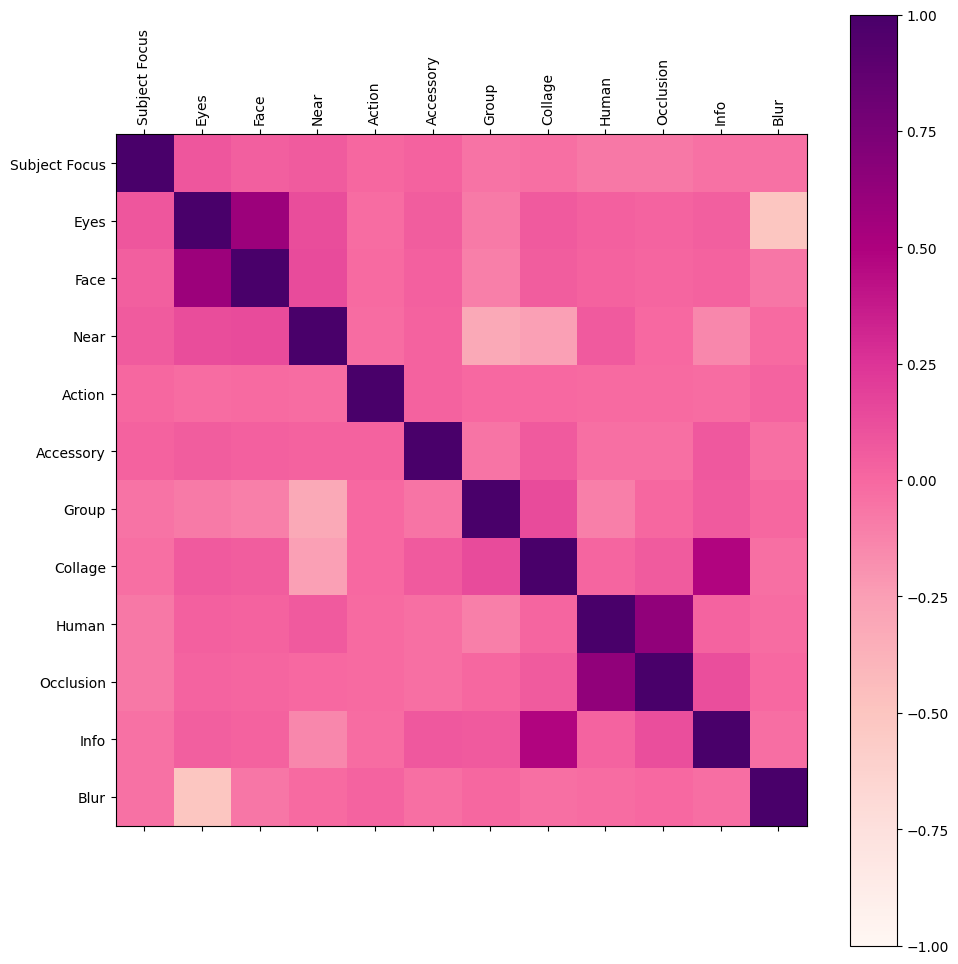

In [5]:
# This EDA plot is not required for submission; keep but make robust to any column count.
correlations = X.corr(numeric_only=True)
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)
cax = ax.matshow(correlations, vmin=-1, vmax=1, cmap="RdPu")
fig.colorbar(cax)
ticks = np.arange(0, len(X.columns), 1)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(X.columns, rotation=90)
ax.set_yticklabels(X.columns)
plt.tight_layout()
plt.show()



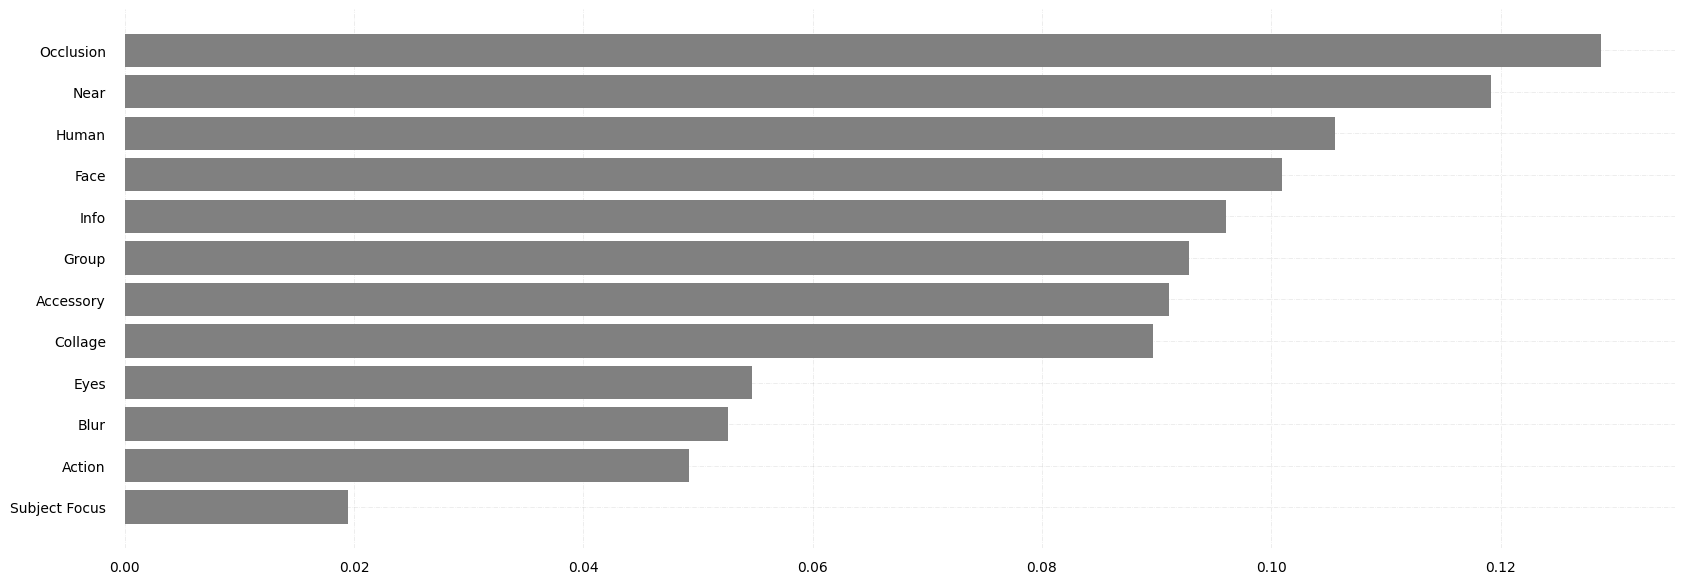

In [6]:
# Feature importance (not required for training, kept for parity)
model = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
model.fit(X, y)
importance1 = model.feature_importances_

d = pd.DataFrame()
d["imp"] = importance1
d["f"] = X.columns
d = d.sort_values("imp", ascending=False)

fig, ax = plt.subplots(figsize=(20, 7))
ax.barh(d.f, d.imp, color="grey")
ax.xaxis.set_ticks_position("none")
ax.yaxis.set_ticks_position("none")
ax.xaxis.set_tick_params(pad=5)
ax.yaxis.set_tick_params(pad=10)
for s in ["top", "bottom", "left", "right"]:
    ax.spines[s].set_visible(False)
ax.grid(True, color="grey", linestyle="-.", linewidth=0.5, alpha=0.2)
ax.invert_yaxis()
plt.show()



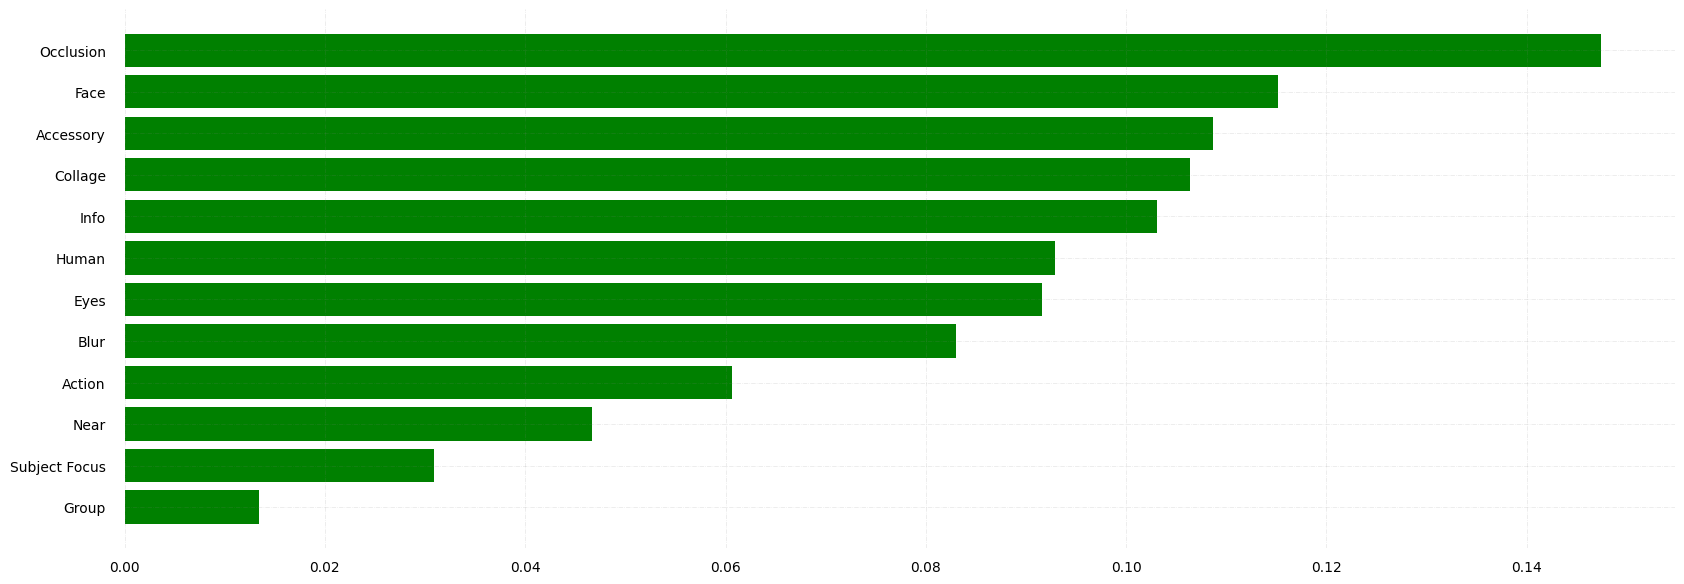

In [7]:
model = ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1)
model.fit(X, y)
importance2 = model.feature_importances_

d = pd.DataFrame()
d["imp"] = importance2
d["f"] = X.columns
d = d.sort_values("imp", ascending=False)

fig, ax = plt.subplots(figsize=(20, 7))
ax.barh(d.f, d.imp, color="green")
ax.xaxis.set_ticks_position("none")
ax.yaxis.set_ticks_position("none")
ax.xaxis.set_tick_params(pad=5)
ax.yaxis.set_tick_params(pad=10)
for s in ["top", "bottom", "left", "right"]:
    ax.spines[s].set_visible(False)
ax.grid(True, color="grey", linestyle="-.", linewidth=0.5, alpha=0.2)
ax.invert_yaxis()
plt.show()



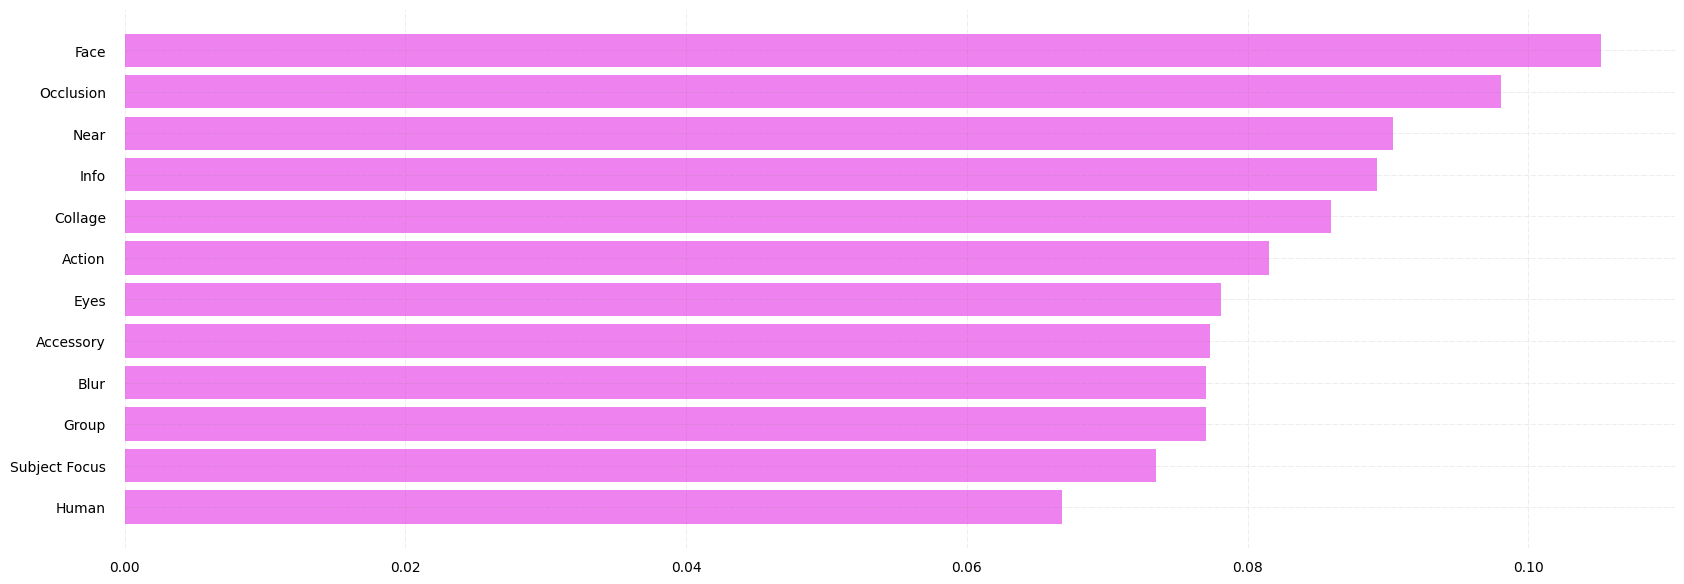

In [8]:
# Keep default-ish XGBRegressor, just pin random_state for determinism in Kaggle runs.
model = XGBRegressor(
    random_state=RANDOM_STATE,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    objective="reg:squarederror",
    n_jobs=-1,
)
model.fit(X, y)
importance3 = model.feature_importances_

d = pd.DataFrame()
d["imp"] = importance3
d["f"] = X.columns
d = d.sort_values("imp", ascending=False)

fig, ax = plt.subplots(figsize=(20, 7))
ax.barh(d.f, d.imp, color="violet")
ax.xaxis.set_ticks_position("none")
ax.yaxis.set_ticks_position("none")
ax.xaxis.set_tick_params(pad=5)
ax.yaxis.set_tick_params(pad=10)
for s in ["top", "bottom", "left", "right"]:
    ax.spines[s].set_visible(False)
ax.grid(True, color="grey", linestyle="-.", linewidth=0.5, alpha=0.2)
ax.invert_yaxis()
plt.show()



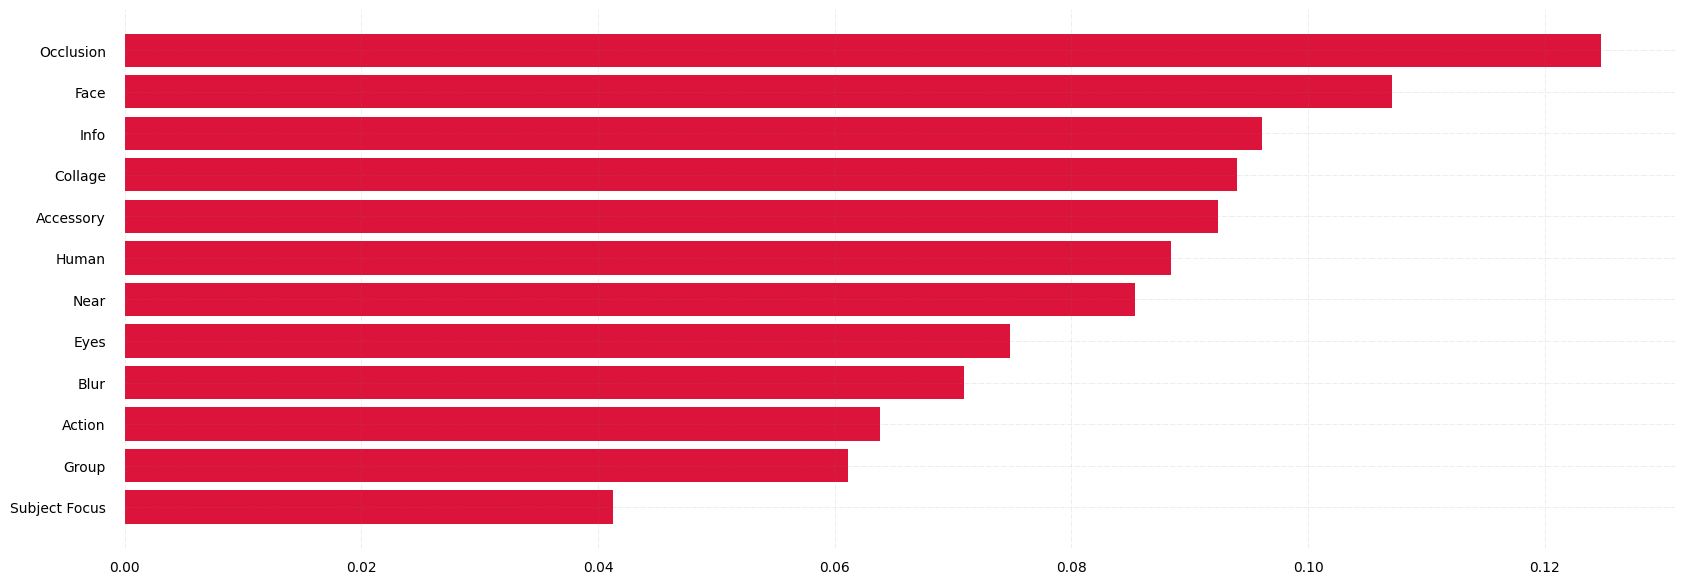

In [9]:
importance = (importance1 + importance2 + importance3) / 3.0

d = pd.DataFrame()
d["imp"] = importance
d["f"] = X.columns
d = d.sort_values("imp", ascending=False)

fig, ax = plt.subplots(figsize=(20, 7))
ax.barh(d.f, d.imp, color="crimson")
ax.xaxis.set_ticks_position("none")
ax.yaxis.set_ticks_position("none")
ax.xaxis.set_tick_params(pad=5)
ax.yaxis.set_tick_params(pad=10)
for s in ["top", "bottom", "left", "right"]:
    ax.spines[s].set_visible(False)
ax.grid(True, color="grey", linestyle="-.", linewidth=0.5, alpha=0.2)
ax.invert_yaxis()
plt.show()



In [10]:
rf = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
et = ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1)
xgb = XGBRegressor(
    random_state=RANDOM_STATE,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    objective="reg:squarederror",
    n_jobs=-1,
)



In [11]:
test_path = os.path.join(DATA_DIR, "test.csv")
testdf = pd.read_csv(test_path)
xpred = testdf.drop(["Id"], axis=1).values



In [12]:
# Fix: original code built y_pred_all as a list of (n,1) arrays using vstack incorrectly,
# then sum(list) could produce an int and break iteration. Here we accumulate with a numpy array.
y_pred_all = np.zeros(xpred.shape[0], dtype=np.float64)

for fold in range(5):
    train = df[df["kfold"] != fold]
    valid = df[df["kfold"] == fold]

    xtrain = train.drop(["Id", "Pawpularity", "kfold"], axis=1).values
    ytrain = train["Pawpularity"].values

    rf = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
    et = ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1)
    xgb = XGBRegressor(
        random_state=RANDOM_STATE,
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        objective="reg:squarederror",
        n_jobs=-1,
    )

    rf.fit(xtrain, ytrain)
    et.fit(xtrain, ytrain)
    xgb.fit(xtrain, ytrain)

    ypred1 = rf.predict(xpred)
    ypred2 = et.predict(xpred)
    ypred3 = xgb.predict(xpred)

    ypred = (ypred1 + ypred2 + ypred3) / 3.0
    y_pred_all += ypred / 5.0



In [13]:
# Fix: competition requires predictions between 1 and 100.
# Clipping avoids invalid submissions and is consistent with the target's domain.
y_pred_all = np.clip(y_pred_all, 1.0, 100.0)

testdf["Pawpularity"] = y_pred_all



In [14]:
# Produce valid submission with required columns and .csv suffix
sub_path = "submission.csv"
testdf[["Id", "Pawpularity"]].to_csv(sub_path, index=False)
print(f"Wrote submission to: {sub_path}")
print(testdf[["Id", "Pawpularity"]].head())

Wrote submission to: submission.csv
                                 Id  Pawpularity
0  ee51b99832f1ba868f646df93d2b6b81    37.937275
1  caddfb3f8bff9c4b95dbe022018eea21    43.364763
2  582eeabd4a448a53ebb79995888a4b0b    37.232996
3  afc1ad7f0c5eea880759d09e77f7deee    37.937275
4  d5bdf3446e86ce4ec67ce7a00f1cccc2    29.908855
